In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")

import polars as pl, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap

from src.features import FEATURES

In [2]:
feat = pl.read_parquet("../data/processed/features.parquet")
fraud = feat.filter(pl.col("isFraud") == 1).to_pandas().reset_index(drop=True)

print("Fraud cases:", len(fraud))
print(fraud["type"].value_counts())

Fraud cases: 8213
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


In [3]:
rows = []
for c in FEATURES:
    top_share = fraud[c].value_counts(normalize=True).iloc[0]
    rows.append({"feature": c, "unique_values": fraud[c].nunique(),
                 "share_of_most_common_value": round(top_share, 3)})
variety = pd.DataFrame(rows).sort_values("share_of_most_common_value", ascending=False)
display(variety)

kept = [r.feature for r in variety.itertuples()
        if r.share_of_most_common_value < 0.99 and r.feature != "is_transfer"]
print("Features used for clustering:", kept)

,feature,unique_values,share_of_most_common_value
4,orig_zero_bal,2,0.995
5,drains_account,2,0.977
6,is_round,2,0.963
14,dest_amt_24h,791,0.904
13,dest_txn_24h,23,0.904
8,is_night,2,0.757
9,dest_prior_txn,39,0.673
12,dest_is_new,2,0.673
10,dest_prior_amt,2690,0.673
11,dest_age_hours,616,0.673


Features used for clustering: ['drains_account', 'is_round', 'dest_amt_24h', 'dest_txn_24h', 'is_night', 'dest_prior_txn', 'dest_is_new', 'dest_prior_amt', 'dest_age_hours', 'hour', 'log_amount', 'amt_to_bal', 'oldbalanceOrg']


In [4]:
LOG_COLS = ["oldbalanceOrg", "amt_to_bal", "dest_prior_txn", "dest_prior_amt",
            "dest_age_hours", "dest_txn_24h", "dest_amt_24h"]

def make_X(df):
    X = pd.DataFrame(index=df.index)
    for c in kept:
        if c == "hour":
            continue
        X[c] = np.log1p(df[c]) if c in LOG_COLS else df[c]
    if "hour" in kept:
        X["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
        X["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    return X

scaler = StandardScaler().fit(make_X(fraud))
Xs = scaler.transform(make_X(fraud))
print(Xs.shape)

(8213, 14)


k=2: silhouette = 0.386
k=3: silhouette = 0.388
k=4: silhouette = 0.398
k=5: silhouette = 0.354
k=6: silhouette = 0.363
k=7: silhouette = 0.353
k=8: silhouette = 0.368


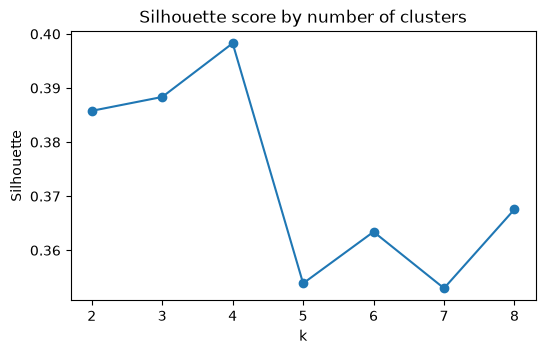

Best k: 4


In [5]:
scores = {}
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels, sample_size=5000, random_state=0)
    print(f"k={k}: silhouette = {scores[k]:.3f}")

plt.figure(figsize=(6, 3.5))
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.title("Silhouette score by number of clusters"); plt.xlabel("k"); plt.ylabel("Silhouette")
plt.savefig("../reports/figures/silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

BEST_K = max(scores, key=scores.get)
print("Best k:", BEST_K)

In [6]:
km = KMeans(n_clusters=BEST_K, n_init=10, random_state=0).fit(Xs)
fraud["cluster"] = km.labels_

emb5 = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=5, random_state=42).fit_transform(Xs)
fraud["hdbscan"] = HDBSCAN(min_cluster_size=100).fit_predict(emb5)

print("K-means cluster sizes:\n", fraud["cluster"].value_counts().sort_index())
print("\nHDBSCAN cluster sizes (-1 = noise):\n", fraud["hdbscan"].value_counts().sort_index())

mask = fraud["hdbscan"] != -1
print("\nAgreement between methods (adjusted Rand index, 1 = identical):",
      round(adjusted_rand_score(fraud.loc[mask, "cluster"], fraud.loc[mask, "hdbscan"]), 3))

K-means cluster sizes:
 cluster
0     776
1    5513
2    1899
3      25
Name: count, dtype: int64

HDBSCAN cluster sizes (-1 = noise):
 hdbscan
-1      838
 0      460
 1      118
 2     1358
 3      377
 4      213
 5      447
 6      256
 7      164
 8      119
 9      168
 10     130
 11     154
 12     608
 13     531
 14     188
 15     393
 16     620
 17     888
 18     183
Name: count, dtype: int64

Agreement between methods (adjusted Rand index, 1 = identical): 0.176


In [7]:
fraud["hdbscan_big"] = HDBSCAN(min_cluster_size=400).fit_predict(emb5)
print("HDBSCAN (big groups) sizes:\n", fraud["hdbscan_big"].value_counts().sort_index())

mask = fraud["hdbscan_big"] != -1
print("\nAgreement with k-means:",
      round(adjusted_rand_score(fraud.loc[mask, "cluster"], fraud.loc[mask, "hdbscan_big"]), 3))

HDBSCAN (big groups) sizes:
 hdbscan_big
-1     461
 0     546
 1     762
 2    1313
 3    3773
 4    1358
Name: count, dtype: int64

Agreement with k-means: 0.6


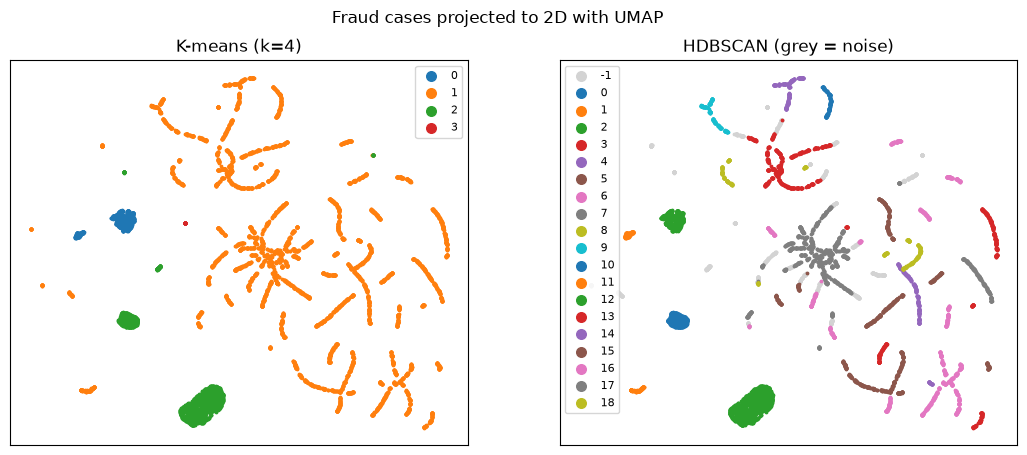

In [8]:
emb2 = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42).fit_transform(Xs)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, col, title in [(ax[0], "cluster", f"K-means (k={BEST_K})"),
                      (ax[1], "hdbscan", "HDBSCAN (grey = noise)")]:
    for lab in sorted(fraud[col].unique()):
        pts = emb2[fraud[col] == lab]
        a.scatter(pts[:, 0], pts[:, 1], s=3, label=str(lab),
                  color="lightgrey" if lab == -1 else None)
    a.set_title(title); a.set_xticks([]); a.set_yticks([])
    a.legend(markerscale=4, fontsize=8)
plt.suptitle("Fraud cases projected to 2D with UMAP")
plt.savefig("../reports/figures/umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
profile = (fraud.groupby("cluster")
                .agg(cases=("amount", "size"),
                     median_amount=("amount", "median"),
                     total_value=("amount", "sum"),
                     median_sender_balance=("oldbalanceOrg", "median"),
                     pct_empties_account=("drains_account", "mean"),
                     pct_transfer=("is_transfer", "mean"),
                     pct_night=("is_night", "mean"),
                     median_hour=("hour", "median"),
                     pct_new_receiver=("dest_is_new", "mean")))
profile["share_of_cases"] = profile["cases"] / profile["cases"].sum()
profile["share_of_value"] = profile["total_value"] / profile["total_value"].sum()
profile = profile.round(3)
display(profile)

profile.to_csv("../dashboard/data/cluster_profiles.csv")

,cases,median_amount,total_value,median_sender_balance,pct_empties_account,pct_transfer,pct_night,median_hour,pct_new_receiver,share_of_cases,share_of_value
cluster,,,,,,,,,,,
0,776,416135.085,1.020298e+09,416135.085,0.996,0.001,0.205,12.0,0.00,0.094,0.085
1,5513,448265.080,8.237650e+09,448266.860,0.972,0.742,0.246,11.0,1.00,0.671,0.683
2,1899,426323.380,2.788932e+09,426323.380,0.996,0.000,0.253,11.0,0.00,0.231,0.231
3,25,229909.570,9.535071e+06,0.000,0.000,0.160,0.040,14.0,0.44,0.003,0.001


In [10]:
hist_cols = ["dest_prior_txn", "dest_prior_amt", "dest_age_hours", "dest_txn_24h", "dest_amt_24h"]
check = fraud.groupby("cluster")[hist_cols].median().round(1)
check["pct_receiver_active_last_24h"] = (fraud["dest_txn_24h"] > 0).groupby(fraud["cluster"]).mean().round(3)
check

,dest_prior_txn,dest_prior_amt,dest_age_hours,dest_txn_24h,dest_amt_24h,pct_receiver_active_last_24h
cluster,,,,,,
0,4.0,841523.7,41.0,1.0,292312.3,1.00
1,0.0,0.0,0.0,0.0,0.0,0.00
2,3.0,576720.9,234.0,0.0,0.0,0.00
3,1.0,44170.1,3.0,1.0,44170.1,0.56


## Fraud typologies

| Cluster | Name | What defines it | Share of cases / value | Suggested action |
|---|---|---|---|---|
| 1 | Transfer to a brand-new account | Empties the account into a never-seen receiver; mostly transfers | 67% / 68% | Hold large account-emptying payments to new payees and confirm with the customer |
| 0 | Cash-out through a busy, recently opened account | Receiver ~2 days old, active in the last 24h in all cases | 9% / 9% | Monitor receiving accounts for rapid incoming activity; review likely mule accounts |
| 2 | Cash-out through an established, quiet account | Receiver ~10 days old, no activity in the last 24h | 23% / 23% | Flag dormant accounts that suddenly receive a full account balance |
| 3 | Fraud from zero-balance accounts | Sender balance £0; does not empty the account; smaller amounts | 0.3% / 0.1% | Low priority; likely a data or simulation quirk |

Although payment type was excluded from clustering, the clusters still separate transfers (to brand-new accounts) from cash-outs (through known accounts), rediscovering PaySim's two-step fraud pattern from behaviour alone. Clusters 0 and 2 are both cash-outs through known receivers; they are separated by receiver recency and activity (active in the last 24h vs quiet).

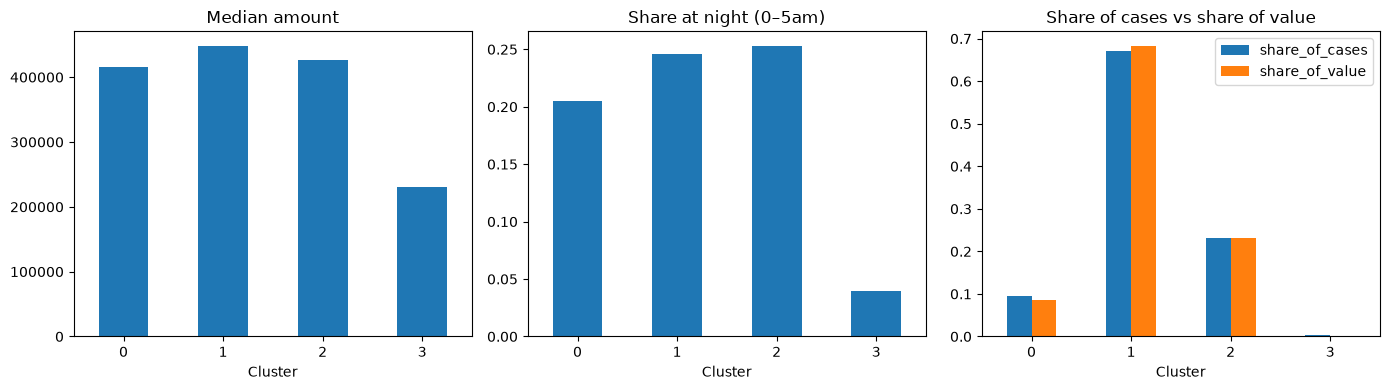

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
profile["median_amount"].plot.bar(ax=ax[0], title="Median amount")
profile["pct_night"].plot.bar(ax=ax[1], title="Share at night (0–5am)")
profile[["share_of_cases", "share_of_value"]].plot.bar(ax=ax[2], title="Share of cases vs share of value")
for a in ax: a.set_xlabel("Cluster"); a.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
scored = pd.read_parquet("../data/processed/test_scored.parquet")
test_fraud = scored[scored["isFraud"] == 1].copy()
test_fraud["cluster"] = km.predict(scaler.transform(make_X(test_fraud)))
test_fraud["caught"] = test_fraud["score"] >= 0.01

(test_fraud.groupby("cluster")
           .agg(test_cases=("caught", "size"), caught_rate=("caught", "mean"),
                missed=("caught", lambda s: (~s).sum())))

,test_cases,caught_rate,missed
cluster,,,
0,81,1.000000,0
1,2710,0.998893,3
2,1229,1.000000,0


## Key takeaways
- Clustered 8,213 fraud cases on behaviour, excluding payment type. One near-constant feature (orig_zero_bal, identical for 99.5% of fraud) was dropped.
- k = 4 chosen by silhouette score (0.398; k = 2–4 nearly tied at 0.386–0.398, indicating moderate, overlapping structure), with each cluster checked to be meaningfully distinct.
- Robustness: HDBSCAN with default settings found ~19 fine-grained clusters (ARI 0.176 vs k-means), but with comparable granularity (min cluster size 400) it found 5 broad clusters and agreed substantially with k-means (ARI 0.6).
- Four typologies:
  - **Transfer to a brand-new account** (67% of cases, 68% of value)
  - **Cash-out through a busy, recently opened account** (9%): receiver ~2 days old and active in the last 24h
  - **Cash-out through an established, quiet account** (23%): receiver ~10 days old with no recent activity
  - **Fraud from zero-balance accounts** (0.3%): rare, smaller amounts, likely a data quirk
- The clustering rediscovered PaySim's two-step fraud pattern (transfer to a fresh account, then cash out) without being given payment type.
- **Model performance by typology (test set):** both cash-out typologies were caught 100% of the time (81 and 1,229 cases). "Transfer to a brand-new account" was caught 99.9% of the time (2,707 of 2,710); all 3 missed frauds fall in this group and are partial transfers from very large accounts that did not empty the account. No zero-balance-account fraud occurred in the test period.
- **Next step suggested by this analysis:** add a feature targeting large partial transfers to brand-new accounts, the one pattern the model misses.
- **Limitation:** receiver-history features are correlated and carry extra weight in the clustering; real-world fraud would likely show more, and messier, typologies than PaySim's simulator.